# DSCI 503 - Homework 07
## Ben Miller

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression

## Problem 1: NYC Restaurants Dataset

In [2]:
nyc = pd.read_csv('nyc.txt', sep='\t')
nyc.head(10)

,Price,Food,Decor,Service,Wait,East
0,43,22,18,20,36,0
1,32,20,19,19,22,0
2,34,21,13,18,20,0
3,41,20,20,17,25,0
4,54,24,19,21,32,0
5,52,22,22,21,15,0
6,34,22,16,21,25,0
7,34,20,18,21,21,1
8,39,22,19,22,23,1
9,44,21,17,19,27,1


In [3]:
X1 = nyc.loc[:, ['Food', 'Decor', 'Service', 'Wait', 'East']].values
y1 = nyc.loc[:, 'Price'].values

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X1, y1, test_size=0.2, random_state=1)
print(f"Training Features Shape: {X_train_1.shape}")
print(f"Test Features Shape:     {X_test_1.shape}")

Training Features Shape: (134, 5)
Test Features Shape:     (34, 5)


In [4]:
nyc_mod = LinearRegression()
nyc_mod.fit(X_train_1, y_train_1)
print(f"Intercept:    {nyc_mod.intercept_}")
print(f"Coefficients: {nyc_mod.coef_}")

Intercept:    -23.755435322488893
Coefficients: [ 1.55693926  2.00700907 -0.25440527  0.09203064  2.63235537]


In [5]:
nyc_train_r2 = nyc_mod.score(X_train_1, y_train_1)
nyc_test_r2 = nyc_mod.score(X_test_1, y_test_1)
print(f"Training r-Squared: {nyc_train_r2}")
print(f"Testing r-Squared:  {nyc_test_r2}")

Training r-Squared: 0.6306317438359605
Testing r-Squared:  0.6245361949850887


In [6]:
test_pred_1 = nyc_mod.predict(X_test_1)
print(f"Observed Prices:  {y_test_1[:10]}")
print(f"Estimated Prices: {test_pred_1[:10].round(2)}")

Observed Prices:  [33 45 54 38 22 47 38 51 46 47]
Estimated Prices: [39.2  38.09 49.35 39.26 19.72 47.4  36.85 50.07 48.26 43.01]


In [7]:
nyc_new = pd.DataFrame(np.array([[22, 12, 20, 15, 0], [18, 19, 22, 34, 1], [25, 22, 18, 36, 0]]))
new_pred_1 = nyc_mod.predict(nyc_new)
print(f"Estimated Prices: {new_pred_1.round(2)}")

Estimated Prices: [30.87 42.57 58.06]


## Problem 2: Diamonds Dataset

In [8]:
diamonds = pd.read_csv('diamonds.txt', sep='\t')
diamonds.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [9]:
# add columns for the natural log of carat and price
diamonds.loc[:, 'ln_carat'] = np.log(diamonds.carat)
diamonds.loc[:, 'ln_price'] = np.log(diamonds.price)
diamonds.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z,ln_carat,ln_price
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,-1.469676,5.786897
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,-1.560648,5.786897
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,-1.469676,5.789960
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,-1.237874,5.811141
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,-1.171183,5.814131


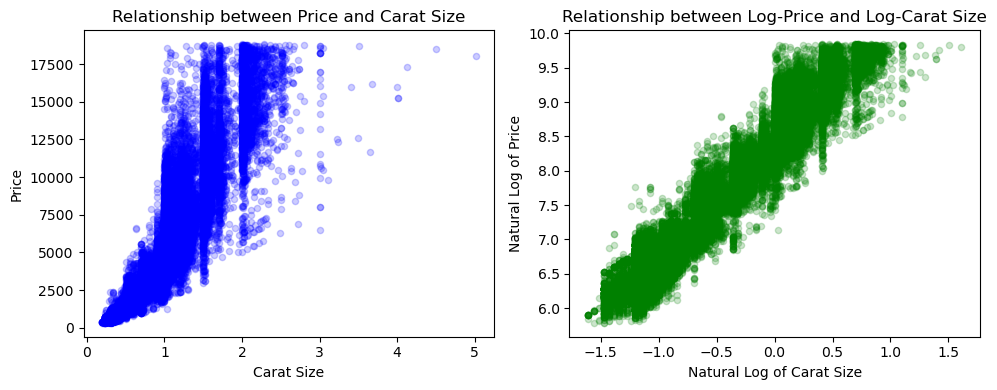

In [10]:
# create scatterplots of carat vs price and ln_carat vs ln_price
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(diamonds.carat, diamonds.price, color='blue', alpha=0.2, s=20)
plt.xlabel("Carat Size")
plt.ylabel("Price")
plt.title("Relationship between Price and Carat Size")

plt.subplot(1, 2, 2)
plt.scatter(diamonds.ln_carat, diamonds.ln_price, color='green', alpha=0.2, s=20)
plt.xlabel("Natural Log of Carat Size")
plt.ylabel("Natural Log of Price")
plt.title("Relationship between Log-Price and Log-Carat Size")

plt.tight_layout()
plt.show()

In [11]:
X2 = diamonds.loc[:, ['ln_carat']].values
y2 = diamonds.loc[:, 'ln_price'].values

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X2, y2, test_size=0.1, random_state=1)
print(f"Training Features Shape: {X_train_2.shape}")
print(f"Test Features Shape:     {X_test_2.shape}")

Training Features Shape: (48546, 1)
Test Features Shape:     (5394, 1)


In [12]:
dia_mod = LinearRegression()
dia_mod.fit(X_train_2, y_train_2)
print(f"Intercept:    {dia_mod.intercept_}")
print(f"Coefficients: {dia_mod.coef_}")

Intercept:    8.448298621179152
Coefficients: [1.67493107]


In [13]:
dia_train_r2 = dia_mod.score(X_train_2, y_train_2)
dia_test_r2 = dia_mod.score(X_test_2, y_test_2)
print(f"Training r-Squared: {dia_train_r2}")
print(f"Testing r-Squared:  {dia_test_r2}")

Training r-Squared: 0.9330053214339236
Testing r-Squared:  0.9328253661298819


In [14]:
test_pred_2 = dia_mod.predict(X_test_2)
print(f"Observed Prices:  {np.exp(y_test_2[:10]).round()}")
print(f"Estimated Prices: {np.exp(test_pred_2[:10]).round()}")

Observed Prices:  [ 564. 5914. 2562.  537. 5964.  984. 5247.  611. 9645. 1162.]
Estimated Prices: [ 729. 6334. 2096.  766. 6334. 1612. 5309. 1048. 9204.  804.]


In [15]:
# predict the prices of diamonds with carat sizes of 0.5, 1.0, 1.5, 2.0, 2.5, and 3.0
diamonds_new = np.array(np.log([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])).reshape(6, 1)

new_pred_2 = dia_mod.predict(diamonds_new)
# transform back to price
print(f"Estimated Prices: {np.exp(new_pred_2).round()}")

Estimated Prices: [ 1462.  4667.  9204. 14902. 21656. 29390.]


## Problem 3: Heart Disease Dataset

In [16]:
hd = pd.read_csv('heart_disease.txt', sep='\t')
hd.head(10)

,age,sex,chest_pain_type,resting_bp,serum_chol,fasting_blood_sugar,electrocardio,max_heart_rate,exercise_induced_angina,oldpeak,slope,major_vessels,thal,heart_disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,1
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,2
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,2
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,2
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,2


In [17]:
X3 = hd.iloc[:, :13].values
y3 = hd.heart_disease.values
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X3, y3, test_size=0.2, random_state=1, stratify=y3)
print(f"Training Features Shape: {X_train_3.shape}")
print(f"Test Features Shape:     {X_test_3.shape}")

Training Features Shape: (216, 13)
Test Features Shape:     (54, 13)


In [18]:
hd_mod = LogisticRegression(solver='lbfgs', penalty=None, max_iter=2000)
hd_mod.fit(X_train_3, y_train_3)
print(f"Intercept:    {hd_mod.intercept_}")
print(f"Coefficients:")
print(hd_mod.coef_)

Intercept:    [-9.86225764]
Coefficients:
[[-0.03353426  1.80193705  0.75396218  0.02514719  0.01437352 -0.69897975
   0.32598769 -0.01949064  0.73748709  0.36630297  0.28060515  1.07611602
   0.38437045]]


In [19]:
train_acc = hd_mod.score(X_train_3, y_train_3)
test_acc = hd_mod.score(X_test_3, y_test_3)
print(f"Training Accuracy: {train_acc}")
print(f"Testing Accuracy:  {test_acc}")

Training Accuracy: 0.8472222222222222
Testing Accuracy:  0.8148148148148148


In [20]:
test_pred_3 = hd_mod.predict(X_test_3)
print(f"Observed Labels:  {y_test_3[:20]}")
print(f"Predicted Labels: {test_pred_3[:20]}")

Observed Labels:  [2 2 2 1 1 2 1 1 2 1 2 1 1 1 2 1 1 1 2 1]
Predicted Labels: [2 2 2 1 1 2 1 1 2 1 2 1 1 1 2 1 1 1 2 1]


In [21]:
hd_proba = hd_mod.predict_proba(X_test_3)
hd_proba_dataframe = pd.DataFrame(hd_proba, columns=['1: No Heart Disease', '2: Heart Disease'])
hd_proba_dataframe.head(10)

,1: No Heart Disease,2: Heart Disease
0,0.011697,0.988303
1,0.043211,0.956789
2,0.039736,0.960264
3,0.848065,0.151935
4,0.873780,0.126220
5,0.051735,0.948265
6,0.920747,0.079253
7,0.944585,0.055415
8,0.010005,0.989995
9,0.996739,0.003261


## Problem 4: Gapminder Dataset

In [22]:
gm = pd.read_csv('gapminder_data.txt', sep='\t')
gm18 = gm[gm.year == 2018]
gm18.head(10)

,country,year,continent,population,life_exp,gdp_per_cap,gini
40112,Afghanistan,2018,asia,36400000,58.7,1870,36.8
40113,Albania,2018,europe,2930000,78.0,12400,29.0
40114,Algeria,2018,africa,42000000,77.9,13700,27.6
40115,Angola,2018,africa,30800000,65.2,5850,42.6
40116,Antigua and Barbuda,2018,americas,103000,77.6,21000,40.0
40117,Argentina,2018,americas,44700000,77.0,18900,42.4
40118,Armenia,2018,europe,2930000,76.0,8660,32.6
40119,Australia,2018,asia,24800000,82.9,45800,32.3
40120,Austria,2018,europe,8750000,81.8,44600,30.5
40121,Azerbaijan,2018,europe,9920000,72.3,16600,32.4


In [23]:
X4 = gm18.loc[:, ['life_exp', 'gdp_per_cap', 'gini']].values
y4 = gm18.continent.values
X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X4, y4, test_size=0.3, random_state=1, stratify=y4)
print(f"Training Features Shape: {X_train_4.shape}")
print(f"Test Features Shape:     {X_test_4.shape}")

Training Features Shape: (128, 3)
Test Features Shape:     (56, 3)


In [24]:
gm_mod = LogisticRegression(solver='lbfgs', penalty=None, max_iter=100000, multi_class='multinomial')
gm_mod.fit(X_train_4, y_train_4)
print(f"Intercept:    {gm_mod.intercept_}")
print(f"Coefficients:")
print(gm_mod.coef_)

C:\Users\BenMi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Intercept:    [ 19.66453522 -28.26292823  16.37839827  -7.78000306]
Coefficients:
[[-3.18440273e-01 -1.45866220e-05  1.07402993e-01]
 [ 2.42553060e-01 -2.73596314e-05  2.73094312e-01]
 [-1.80128874e-01  3.46507696e-05 -6.63165485e-02]
 [ 2.56016014e-01  7.29563701e-06 -3.14180834e-01]]


C:\Users\BenMi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
train_acc_4 = gm_mod.score(X_train_4, y_train_4)
test_acc_4 = gm_mod.score(X_test_4, y_test_4)
print(f"Training Accuracy: {round(train_acc_4, 4)}")
print(f"Testing Accuracy:  {round(test_acc_4, 4)}")

Training Accuracy: 0.7188
Testing Accuracy:  0.6786


In [26]:
test_pred_4 = gm_mod.predict(X_test_4)
print(f"Observed Labels:  {y_test_4[:8]}")
print(f"Predicted Labels: {test_pred_4[:8]}")

Observed Labels:  ['americas' 'asia' 'asia' 'asia' 'africa' 'europe' 'asia' 'europe']
Predicted Labels: ['americas' 'europe' 'africa' 'asia' 'europe' 'europe' 'africa' 'europe']


In [27]:
test_proba_4 = gm_mod.predict_proba(X_test_4)
test_proba_4_dataframe = pd.DataFrame(test_proba_4, columns=['africa', 'americas', 'asia', 'europe'])
test_proba_4_dataframe.head(10)

,africa,americas,asia,europe
0,0.067401,0.480915,0.311900,0.139784
1,0.002967,0.080125,0.124877,0.792032
2,0.812608,0.000108,0.187202,0.000082
3,0.312028,0.081856,0.562884,0.043232
4,0.002366,0.002810,0.068687,0.926136
5,0.012770,0.006636,0.331035,0.649559
6,0.720641,0.008729,0.269520,0.001110
7,0.000108,0.000432,0.016750,0.982709
8,0.008211,0.002517,0.244131,0.745141
9,0.129383,0.112051,0.457770,0.300796


In [28]:
gm_new = pd.DataFrame(np.array([[75, 5000, 30], 
                                [75, 5000, 40], 
                                [75, 5000, 50] , 
                                [75, 20000, 30], 
                                [75, 20000, 40], 
                                [75, 20000, 50]]))

gm_new_pred = gm_mod.predict_proba(gm_new).round(3)
gm_new_proba_dataframe = pd.DataFrame(gm_new_pred, columns=['africa', 'americas', 'asia', 'europe'])
gm_new_proba_dataframe

,africa,americas,asia,europe
0,0.031,0.012,0.261,0.695
1,0.207,0.421,0.304,0.068
2,0.084,0.894,0.022,0.000
3,0.020,0.006,0.352,0.622
4,0.161,0.271,0.495,0.073
5,0.097,0.851,0.052,0.001


According to our model:
* Country 0 is most likely in europe.
* Country 1 is most likely in americas.
* Country 2 is most likely in americas.
* Country 3 is most likely in asia.
* Country 4 is most likely in asia.
* Country 5 is most likely in americas.